<a href="https://colab.research.google.com/github/mushrifahamed/DL-Assignment1/blob/custom_cnn/Brain_Tumor_CNN_Model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Step 1: Set Up Your Notebook Environment**

1. **Import libraries**
   You’ll need standard libraries for deep learning, image handling, and plotting:

In [ ]:
# TensorFlow/Keras for building the CNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# For numerical operations and plotting
import numpy as np
import matplotlib.pyplot as plt
import os

## **Step 2: Prepare the Dataset**

Since your dataset is from Kaggle:

1. **Upload Kaggle API token (`kaggle.json`) to Colab**.
2. **Install Kaggle package** if not installed:

In [ ]:
!pip install kaggle

3. **Set up Kaggle credentials in Colab**:

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

4. **Download the dataset**:

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip -d /content/brain_tumor_dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/brain_tumor_dataset/Testing/glioma/Te-glTr_0000.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
y


5. **Check data** (to understand data):

In [ ]:
print("Dataset Statistics:")
print(f"Training samples per class:")
for class_name in train_generator.class_indices.keys():
    count = sum(1 for category in os.listdir(f'/content/brain_tumor_dataset/Training/{class_name}'))
    print(f"  {class_name}: {count}")

print(f"\nDataset Overview:")
print(f"Total training samples: {len(train_generator.classes)}")
print(f"Total validation samples: {len(validation_generator.classes)}")
print(f"Total test samples: {len(test_generator.classes)}")

print(f"\nClass ratios:")
for class_name, idx in train_generator.class_indices.items():
    ratio = len(train_generator.classes[train_generator.classes == idx]) / len(train_generator.classes)
    print(f"  {class_name}: {ratio:.3f}")

Dataset Statistics:
Training samples per class:
  glioma: 1321
  meningioma: 1339
  notumor: 1595
  pituitary: 1457

Dataset Overview:
Total training samples: 4571
Total validation samples: 1141
Total test samples: 1311

Class ratios:
  glioma: 0.231
  meningioma: 0.235
  notumor: 0.279
  pituitary: 0.255


## **Step 3: Image Preprocessing**
We handle the preprocessing of the image data. This involves resizing and normalizing the images using ImageDataGenerator and setting up data generators for training, validation, and testing.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,  # Increase from 10
    width_shift_range=0.1,  # Increase from 0.05
    height_shift_range=0.1,  # Increase from 0.05
    shear_range=0.1,  # ADD THIS
    zoom_range=0.1,  # Increase from 0.05
    horizontal_flip=True,
    vertical_flip=True,  # ADD THIS - useful for medical images
    brightness_range=[0.8, 1.2],  # ADD THIS - important for medical imaging
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255) # No augmentation for testing

train_generator = train_datagen.flow_from_directory(
    '/content/brain_tumor_dataset/Training', # Point to Training folder
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training' # Use the training subset
)

validation_generator = train_datagen.flow_from_directory(
    '/content/brain_tumor_dataset/Training', # Point to Training folder
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation', # Use the validation subset
    shuffle=False # Set shuffle to False for consistent evaluation
)

test_generator = test_datagen.flow_from_directory(
    '/content/brain_tumor_dataset/Testing', # Point to Testing folder
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Keep data in order for evaluation
)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


##**Step 4: Build the CNN Model**
Here, we define the architecture of the Convolutional Neural Network (CNN) model using TensorFlow/Keras. This includes adding convolutional layers, pooling layers, flatten layer, and dense layers. The model is then compiled with an optimizer and loss function.

**Model Architecture Design Decisions:**
- Conv layers with increasing filters (64→128→256→256) to capture hierarchical features
- MaxPooling2D after each conv block to reduce spatial dimensions and prevent overfitting
- Dropout(0.5) before final dense layer for regularization
- Dense(256) hidden layer for feature combination
- Softmax output for 4-class classification

In [ ]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')   # 4 classes
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,321,476 (12.67 MB)

 Trainable params: 3,321,476 (12.67 MB)

 Non-trainable params: 0 (0.00 B)

##**Step 5: Handle Class Imbalance and Train the Model**
We address the class imbalance in the dataset by computing class weights. Then, we train the CNN model using the training data, with validation data for monitoring and early stopping to prevent overfitting.

In [ ]:
# Compute weights for each class to handle class imbalance during training
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class indices from train generator
classes = train_generator.classes
class_weights = compute_class_weight('balanced', classes=np.unique(classes), y=classes)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.0811258278145695), 1: np.float64(1.0659981343283582), 2: np.float64(0.8955721003134797), 3: np.float64(0.9800600343053173)}


In [ ]:
# Train the Model
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss doesn't improve for 3 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[early_stop],
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 48s 297ms/step - accuracy: 0.3650 - loss: 1.2754 - val_accuracy: 0.5986 - val_loss: 1.0021
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 246ms/step - accuracy: 0.6166 - loss: 0.8917 - val_accuracy: 0.6126 - val_loss: 1.0016
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 242ms/step - accuracy: 0.6939 - loss: 0.7500 - val_accuracy: 0.6538 - val_loss: 0.9270
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 241ms/step - accuracy: 0.7273 - loss: 0.6798 - val_accuracy: 0.6661 - val_loss: 0.8542
Epoch 5/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 38s 265ms/step - accuracy: 0.7660 - loss: 0.6062 - val_accuracy: 0.6836 - val_loss: 0.8252
Epoch 6/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 37s 240ms/step - accuracy: 0.7854 - loss: 0.5518 - val_accuracy: 0.6652 - val_loss: 0.8844
Epoch 7/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 34s 239ms/step - accuracy: 0.7795 - loss: 0.5638 - val_accuracy: 0.7301 - val_loss: 0.7400
Epoch 8/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 34s 236ms/step - accuracy: 0.8307 - loss: 0

##**Step 6: Visualize Training History**
Here, we visualize the training history of the model by plotting the training and validation accuracy and loss over epochs. We also print the final and best performance metrics.

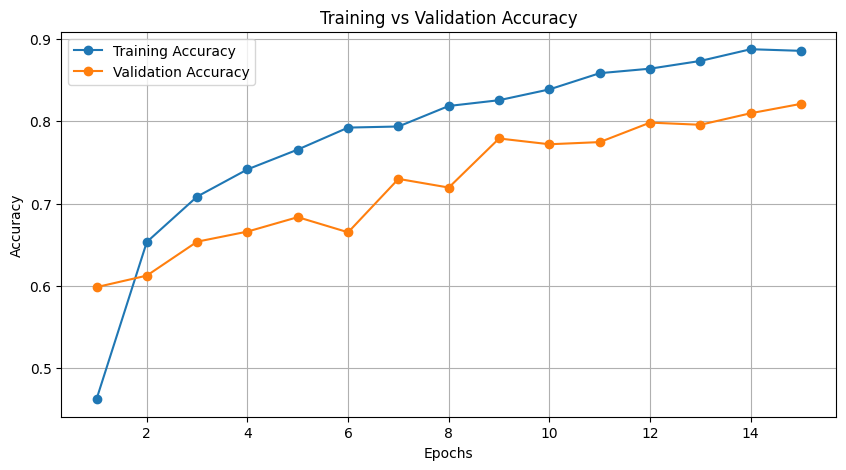

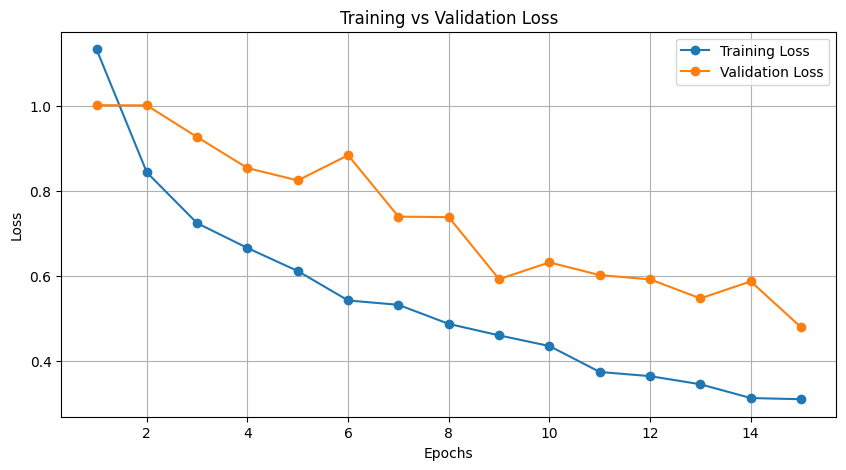

Final Training Accuracy: 88.56%
Final Validation Accuracy: 82.12%
Final Training Loss: 0.3105
Final Validation Loss: 0.4798

Best Validation Accuracy: 82.12% at Epoch 15


In [ ]:
import matplotlib.pyplot as plt

# Get history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# ---- Plot Accuracy ----
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ---- Plot Loss ----
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---- Text Outputs for Easy Reading ----
print("Final Training Accuracy: {:.2f}%".format(acc[-1] * 100))
print("Final Validation Accuracy: {:.2f}%".format(val_acc[-1] * 100))
print("Final Training Loss: {:.4f}".format(loss[-1]))
print("Final Validation Loss: {:.4f}".format(val_loss[-1]))

# Compare best epoch
best_epoch = val_acc.index(max(val_acc)) + 1
print("\nBest Validation Accuracy: {:.2f}% at Epoch {}".format(max(val_acc) * 100, best_epoch))


In [ ]:
# Text-only visualization of accuracy & loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

print("\nEpoch | Train Acc | Val Acc | Train Loss | Val Loss")
print("-"*55)

for i in range(len(acc)):
    print("{:5d} | {:9.4f} | {:7.4f} | {:11.4f} | {:8.4f}".format(
        i+1, acc[i], val_acc[i], loss[i], val_loss[i]
    ))

# Show final & best
best_epoch = val_acc.index(max(val_acc)) + 1
print("\nFinal Training Accuracy: {:.2f}%".format(acc[-1] * 100))
print("Final Validation Accuracy: {:.2f}%".format(val_acc[-1] * 100))
print("Final Training Loss: {:.4f}".format(loss[-1]))
print("Final Validation Loss: {:.4f}".format(val_loss[-1]))
print("Best Validation Accuracy: {:.2f}% at Epoch {}".format(max(val_acc) * 100, best_epoch))



Epoch | Train Acc | Val Acc | Train Loss | Val Loss
-------------------------------------------------------
    1 |    0.4625 |  0.5986 |      1.1337 |   1.0021
    2 |    0.6535 |  0.6126 |      0.8440 |   1.0016
    3 |    0.7086 |  0.6538 |      0.7245 |   0.9270
    4 |    0.7416 |  0.6661 |      0.6662 |   0.8542
    5 |    0.7657 |  0.6836 |      0.6119 |   0.8252
    6 |    0.7924 |  0.6652 |      0.5428 |   0.8844
    7 |    0.7937 |  0.7301 |      0.5325 |   0.7400
    8 |    0.8186 |  0.7195 |      0.4876 |   0.7387
    9 |    0.8256 |  0.7791 |      0.4607 |   0.5929
   10 |    0.8388 |  0.7721 |      0.4356 |   0.6323
   11 |    0.8585 |  0.7748 |      0.3746 |   0.6024
   12 |    0.8639 |  0.7984 |      0.3648 |   0.5924
   13 |    0.8733 |  0.7958 |      0.3457 |   0.5476
   14 |    0.8876 |  0.8098 |      0.3133 |   0.5876
   15 |    0.8856 |  0.8212 |      0.3105 |   0.4798

Final Training Accuracy: 88.56%
Final Validation Accuracy: 82.12%
Final Training Loss: 0.3105
F

##**Step 7: Evaluate the Model**

Finally, we evaluate the trained model's performance on the test set. This involves calculating and printing the test accuracy and loss, generating a classification report, and displaying a confusion matrix to assess the model's performance for each class.

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.7522 - loss: 0.6758

Test Accuracy: 81.54%
Test Loss: 0.5283
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step

Classification Report:
              precision    recall  f1-score   support

      glioma       0.89      0.80      0.84       300
  meningioma       0.79      0.49      0.61       306
     notumor       0.75      1.00      0.86       405
   pituitary       0.88      0.92      0.90       300

    accuracy                           0.82      1311
   macro avg       0.83      0.80      0.80      1311
weighted avg       0.82      0.82      0.80      1311



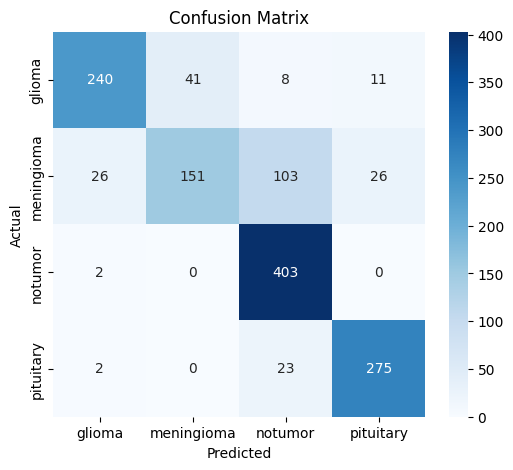

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Evaluate accuracy on test set
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# 2. Get predictions
# Since test_generator shuffles=False, the order is maintained
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Classification report
print("\nClassification Report:")
# Get class names from the generator
class_names = list(test_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Step 8: Save Model Results

In this step, we save the trained model so that it can be loaded and used later without retraining.

In [ ]:
# Save the model
model.save('brain_tumor_cnn_model.keras')
print("Model saved successfully!")

Model saved successfully!


## Step 9: Model Evaluation (Post-Training)

Load the saved model (optional)
If you saved it using ModelCheckpoint, you can reload it for evaluation:

In [ ]:
from tensorflow.keras.models import load_model

# Assuming you saved your best model using ModelCheckpoint during training
# If not, you can skip loading and use the 'model' variable directly
# model = load_model('best_model.h5')

Evaluate on validation/test set

In [ ]:
# Evaluate on the validation set
loss, accuracy = model.evaluate(validation_generator)
print(f"Validation Loss: {loss:.4f}, Validation Accuracy: {accuracy:.4f}")

# If you want to evaluate on the test set instead, use test_generator
# loss, accuracy = model.evaluate(test_generator)
# print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.7905 - loss: 0.4827
Validation Loss: 0.4887, Validation Accuracy: 0.8177


Predict and generate classification metrics

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get true labels from the generator
y_true = validation_generator.classes

# Predict class probabilities
y_pred_prob = model.predict(validation_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# Classification report (precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(validation_generator.class_indices.keys())))

36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 195ms/step
Confusion Matrix:
[[211  45   1   7]
 [ 10 180  43  34]
 [  4  15 268  32]
 [  0   8   4 279]]

Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.80      0.86       264
  meningioma       0.73      0.67      0.70       267
     notumor       0.85      0.84      0.84       319
   pituitary       0.79      0.96      0.87       291

    accuracy                           0.82      1141
   macro avg       0.83      0.82      0.82      1141
weighted avg       0.83      0.82      0.82      1141

